# 00 · Raw signal diagnostics

Before acquiring anything, check the capture itself. This notebook opens one raw collect and answers a single question: **is this recording usable?**

Almost every "why won't this acquire?" turns out to be visible here — an AGC that was set too low, a capture that is real-valued when the code assumed complex, CW interference sitting in the band, or a front end whose gain drifted mid-collect.

### What you are looking at

A collect is a directory holding a raw IQ file plus a `metadata.yml` describing how it was recorded — sample rate, sample format, RF centre frequency, and which band the channel carries. Nothing in the raw file itself records any of that, which is why the metadata has to travel with it.

### Why every plot below looks like noise

A GNSS signal arrives at roughly −157 dBW. Against thermal noise that is a carrier-to-noise-density ratio of about 35–50 dB‑Hz — but spread over the sampled bandwidth, the SNR is deeply negative: at 22 Msps, a 45 dB‑Hz signal sits about 28 dB *below* the noise floor. Nothing in a histogram or a periodogram will show a satellite.

Correlation is what recovers it. Despreading against the PRN code collapses the signal's bandwidth to the data bandwidth while leaving the noise spread, and that processing gain — roughly `10·log10(T · chip_rate)` — is what lifts the peak above the floor in notebook `01`.

So the question here is not "can I see satellites?" but **"is this the right kind of noise?"**

## 1. Imports

`utils.plotting.setup_default_plotting()` only sets matplotlib rcParams; it has no effect on any signal processing.

In [18]:
import os

import matplotlib.pyplot as plt
import numpy as np
import numpy.fft as fft
import scipy.signal
import tqdm

import utils
from utils import collect_metadata_utils, sample_streaming

utils.plotting.setup_default_plotting()

## 2. Select a collect

`resolve_collect` reads the experiment's `metadata.yml` and returns everything needed to open one band of one collect. Three indices choose what you get, and each prints the list it indexed into — run once, then edit:

| Variable | Selects | Change by |
|---|---|---|
| `experiment_names[...]` | experiment directory | index into the printed experiment list |
| `metadata.collect_ids[...]` | collect within it | index into the printed collect list |
| `channel_config.band_ids[...]` | band within *that collect* | index into the bands that collect's own channel config carries |

**Careful:** `metadata.band_ids` is every band anywhere in the experiment, sorted alphabetically across all collects — it is not the set of bands any one collect carries, and `metadata.band_ids[i]` need not correspond to `metadata.collect_ids[i]`. Always derive `band_id` from the chosen collect's own `channel_config.band_ids`, as below. `resolve_collect` raises if the two disagree.

**Returned:**

- `collect_filepath` — the raw IQ file
- `samp_rate` — complex sample rate
- `sample_params` — on-disk format (bit depth, signed/unsigned, complex/real, I/Q byte order)
- `inter_freq_hz` — the band's intermediate frequency: where the band centre sits relative to the centre of the recorded spectrum. Zero for a baseband capture.

In [19]:
# Runtime config (COLLECTS_PATH etc.) comes from `.env`; see
# utils/environment_variables.py and the README for the template.
collects_dir = utils.environment_variables.get_collects_path()
experiment_names = collect_metadata_utils.list_experiment_names(collects_dir)
print("Available experiments:\n  ", "\n  ".join(experiment_names), sep="")

experiment_name = experiment_names[0]  # index into the list printed above
print(f"\nSelected experiment:\n  {experiment_name}\n")

metadata_filepath = collects_dir / experiment_name / "metadata.yml"
metadata = collect_metadata_utils.load_experiment_metadata_from_file(
    metadata_filepath, print_summary=True
)

collect_id = metadata.collect_ids[2]  # index into the printed collect list

# `metadata.band_ids` lists every band anywhere in the experiment, sorted
# alphabetically -- it is NOT the set of bands this particular collect
# carries, so `metadata.band_ids[i]` and `collect_ids[i]` can point at
# different recordings (seen on the Haleakala experiment: collect RX3 is
# alphabetically first but carries L5, while "L1" is alphabetically first
# among bands). Index into the collect's own channel config instead.
collect_config = metadata.collects[collect_id]
channel_config = metadata.channel_configurations[collect_config.channel_config_id]
band_id = channel_config.band_ids[0]  # index into *this collect's* bands

resolved = collect_metadata_utils.resolve_collect(
    collects_dir, experiment_name, collect_id, band_id
)
collect_filepath = resolved.collect_filepath
samp_rate = resolved.samp_rate
sample_params = resolved.sample_params
inter_freq_hz = resolved.inter_freq_hz

print(f"\nSelected collect:\n  {collect_id}: {band_id}")
print(f"Selected file:\n  {collect_filepath.name}")

Available experiments:
  20210611_121000_011501_HI
  20230324_SURGE_flight2_boulderresrvoir
  20230417_SURGE_L5AERORooftop

Selected experiment:
  20210611_121000_011501_HI

Available collects:
  20210611_121000_RX3: L5
  20210611_121000_RX5: L2
  20210611_121000_RX7: L1

Selected collect:
  20210611_121000_RX7: L1
Selected file:
  20210611_121000_011501_HI_RX7.sc8


## 3. Band coverage

A channel records a slice of spectrum `samp_rate` wide, centred on its RF centre frequency. This plot shows that slice at baseband (left, the numbers you will process) and back at RF (right).

**Check:** each band's centre line sits inside its channel's shaded passband. A centre line outside the box means that band was not captured by that channel, and nothing will acquire on it.

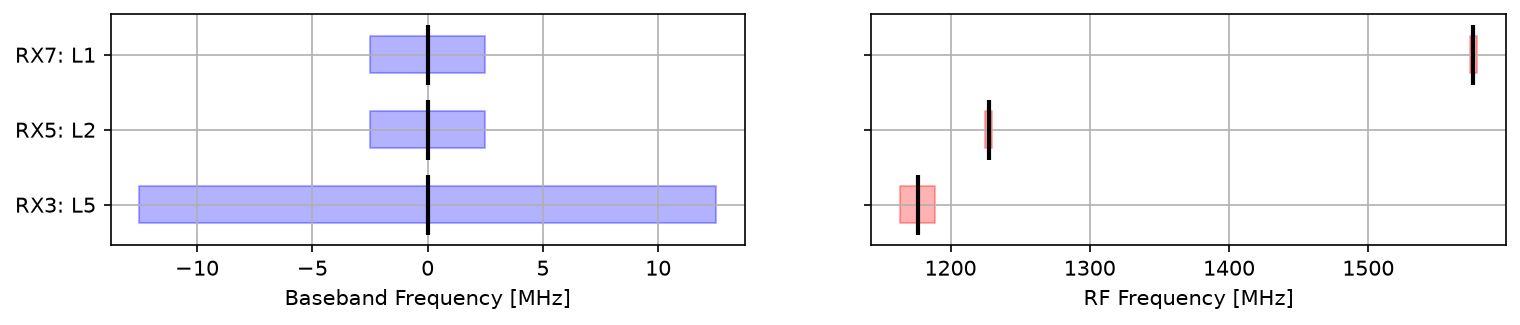

In [20]:
fig = plt.figure(figsize=(12, 2), dpi=150)
utils.plotting.plot_receiver_channel_bands(fig, metadata)

## 4. Read one buffer

Collects here run from 0.5 GB to 32 GB, so read a short buffer from the start. Four steps, repeated by every notebook downstream:

1. **Read raw bytes** into a pre-sized `bytearray`.
2. **Decode to `complex64`** using `sample_params`. These files are `sc8` — signed, complex, 8-bit — two bytes per sample. Other collects use 2-, 4- or 16-bit formats, which is why the format is described in metadata rather than assumed.
3. **Mix down to baseband** by `inter_freq_hz`. A no-op when the capture is already at baseband, but leave it in — it is what makes an IF-centred collect work.
4. **Remove DC.** A constant bias from the front end appears as a spike at 0 Hz and biases the correlation.

**Parameter:** `buffer_duration_ms`. 40 ms is ample for these plots; longer is smoother but slower.

In [21]:
buffer_duration_ms = 100

# Samples and bytes differ: a sample may be complex, and may not be 8 bits.
buffer_size_samples = int(samp_rate * buffer_duration_ms / 1e3)
buffer_size_bytes = sample_streaming.compute_sample_array_size_bytes(
    buffer_size_samples, sample_params.bit_depth, sample_params.is_complex
)
byte_buffer = bytearray(buffer_size_bytes)
sample_buffer = np.zeros(buffer_size_samples, dtype=np.complex64)
baseband_sample_buffer = np.zeros(buffer_size_samples, dtype=np.complex64)

with open(collect_filepath, "rb") as f:
    f.readinto(byte_buffer)

sample_streaming.convert_to_complex64_samples(byte_buffer, sample_buffer, sample_params)

sample_streaming.mixdown_samples(
    sample_buffer,
    baseband_sample_buffer,
    samp_rate,
    0.0,            # initial phase, cycles
    inter_freq_hz,  # frequency to mix off
)

baseband_sample_buffer -= np.mean(baseband_sample_buffer)

## 5. Sample distribution

Histogram of I and Q over the full range the sample format can represent, plus the I/Q scatter.

**Healthy:** Gaussian, zero-mean, occupying a good fraction of the available range; a round, featureless scatter.

| Symptom | Cause |
|---|---|
| Distribution flattened against the rails | AGC too high — clipping |
| Distribution confined to a few LSBs | AGC too low; quantisation loss |
| Q identically zero | real-valued data — check `is_complex` in `metadata.yml` |
| Off-centre or annular scatter | residual DC, or an uncorrected carrier offset |

On the rooftop collect you should see a clean bell plus a small spike at the negative rail — a little clipping, harmless while the bulk of the distribution is well inside the range. Contrast it with the `20230324_092021` collect, whose AGC was effectively off: its distribution collapses to a couple of LSBs, and nothing acquires from it.

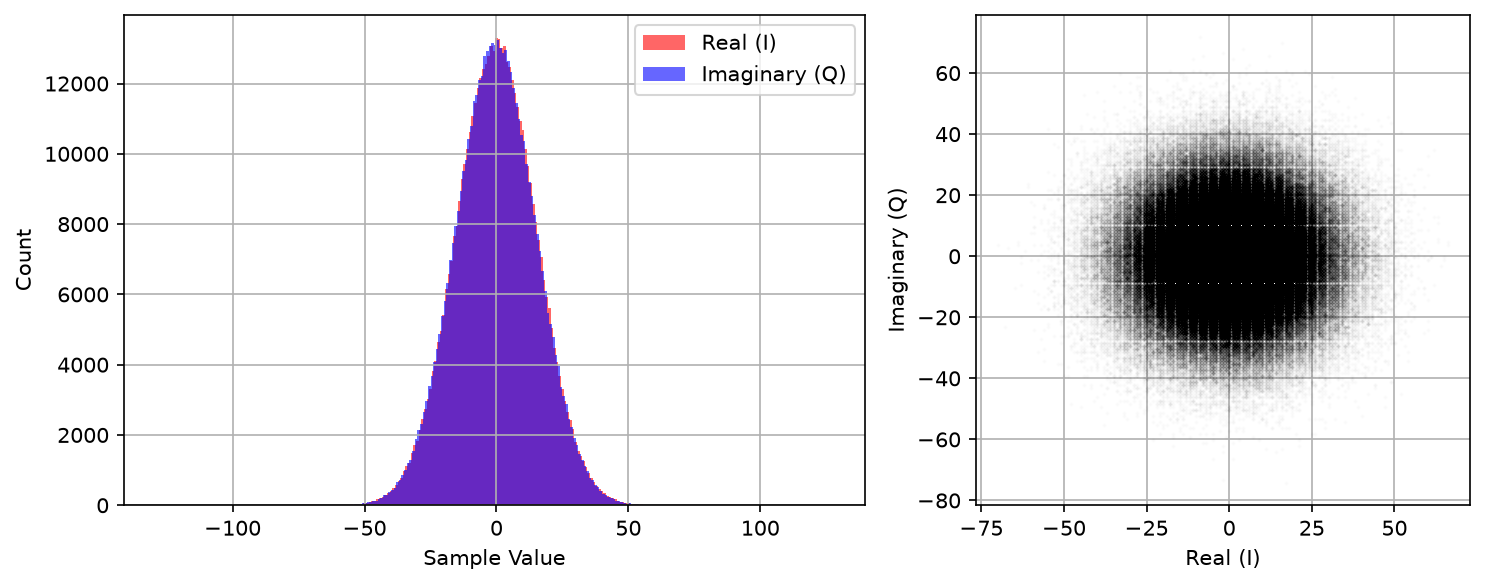

In [22]:
fig = plt.figure(figsize=(10, 4))
utils.plotting.plot_sample_histogram_and_constellation(
    fig, baseband_sample_buffer, bit_depth=sample_params.bit_depth
)
plt.tight_layout()
plt.show()

## 6. Power spectral density

Welch's method: average many short periodograms so the estimate is readable. Grey is the raw capture, black the mixed-down baseband; they coincide when `inter_freq_hz` is 0.

**Expect** the front end's passband — a broad dome rolling off at the edges. A ranging code's main lobe is ±(chip rate) wide, so how much of the plot the signal's spectrum fills depends on the band: a 1.023 Mcps code occupies a narrow centre slice, a 10.23 Mcps code fills most of a 22 MHz span.

**Problems:** a narrow spike is CW interference. A flat, domeless trace suggests the front end delivered nothing. A spike exactly at 0 MHz is residual DC.

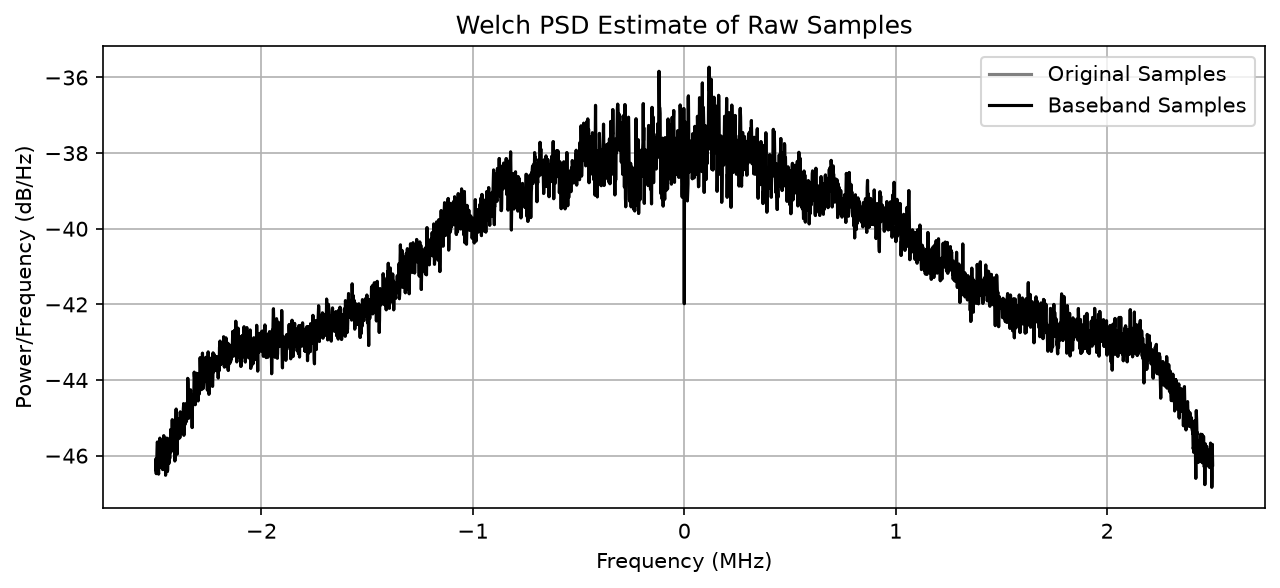

In [23]:
fig = plt.figure(figsize=(10, 4))
utils.plotting.plot_welch_psd(fig, baseband_sample_buffer, samp_rate, sample_buffer)
plt.show()

## 7. Spectrogram over the whole collect

Steps 5–6 saw only the first 40 ms. Gain drifts, antennas move, interference comes and goes, so sweep the entire file at one spectrum per second.

`FileSampleStream(...)` with `skip` reads one buffer then jumps the next `buffer_skip - 1`, sampling the file rather than consuming it.

**Parameters:** `stft_interval_ms` (time resolution) and `periodogram_nperseg` (FFT length — frequency resolution). This is the slow cell; it walks the whole file.

In [24]:
stft_interval_ms = 1000                               # one spectrum per second
buffer_skip = stft_interval_ms // buffer_duration_ms  # buffers skipped between spectra
periodogram_nperseg = 4096                            # FFT length
periodogram_noverlap = 2048                           # overlap within one Welch estimate
stft_freq = fft.fftshift(fft.fftfreq(periodogram_nperseg, 1 / samp_rate))

# Pre-allocate: estimate the spectrum count from the file size.
file_duration_estimate_ms = (
    os.path.getsize(collect_filepath) // buffer_size_bytes * buffer_duration_ms
)
num_windows = file_duration_estimate_ms // stft_interval_ms
periodogram = np.zeros((num_windows, periodogram_nperseg))

with sample_streaming.FileSampleStream(
    collect_filepath,
    sample_params,
    buffer_size_samples,
) as sample_stream:
    sample_buffer_generator = sample_stream.sample_buffer_generator(skip=buffer_skip)
    for i, stft_buffer in enumerate(tqdm.tqdm(sample_buffer_generator, total=num_windows)):
        _, epoch_psd = scipy.signal.welch(
            stft_buffer,
            fs=samp_rate,
            nperseg=periodogram_nperseg,
            noverlap=periodogram_noverlap,
            window="hann",
            return_onesided=False,
            scaling="density",
        )
        periodogram[i, :] = fft.fftshift(epoch_psd)  # negative frequencies on the left

        if i + 1 == num_windows:
            break

100%|█████████▉| 599/600 [00:15<00:00, 38.68it/s]


## 8. Reading the spectrogram

Time left to right, frequency bottom to top, colour is power in dB.

**Healthy:** a steady horizontal band, uniform across the capture.

- **Persistent horizontal lines** — CW interference at a fixed frequency, the most common cause of an otherwise inexplicable acquisition failure.
- **Vertical stripes** — dropped samples or a burst of interference.
- **Colour drifting over time** — the AGC or the antenna's sky view changed. Visible on the balloon flights in this dataset.

On the rooftop collect, look for a thin bright line near **+4.3 MHz** spanning the full width. That is real CW interference inside the band — weak enough that acquisition still succeeds here, and invisible in the histogram.

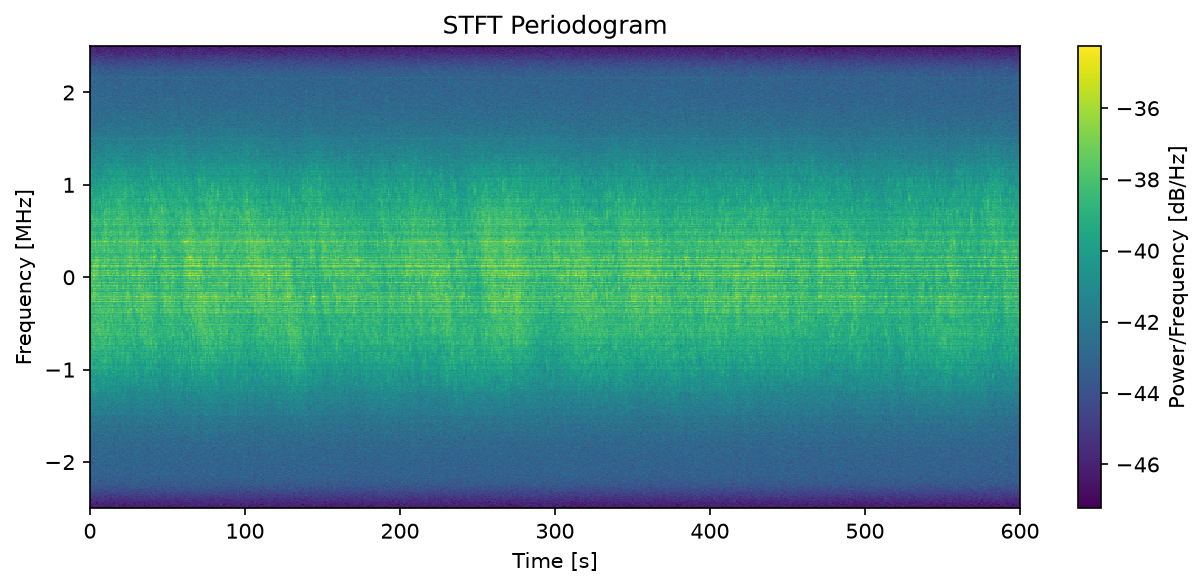

In [25]:
fig = plt.figure(figsize=(10, 4))
utils.plotting.plot_stft_periodogram(
    fig, periodogram, samp_rate, total_duration_s=num_windows * stft_interval_ms / 1e3
)
plt.show()

---

If the collect looks healthy, continue to **`01-acquisition-and-tracking.ipynb`**, which correlates against each satellite's PRN code and pulls the signals out of this noise.